<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle
import requests
import fitz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.

Para el entrenamiento del modelo, se utilizara el libro del desafio 2, 'Las mil y una noches' de la pagina https://www.textos.info

In [2]:
url = 'https://www.textos.info/anonimo/las-mil-y-una-noches/epub'
if not os.path.exists('books'):
    os.makedirs('books')
if not os.path.exists('books/book.epub'):
    response = requests.get(url)
    with open('books/book.epub', 'wb') as f:
        f.write(response.content)

def read_ebook(file_path):
    doc = fitz.open(file_path)
    article_text = ''
    
    for page in doc:
        article_text += page.get_text().replace('\n', ' ')
    
    return article_text.lower()

book_text = read_ebook("./books/book.epub")

MuPDF error: syntax error: css syntax error: unexpected token (OEBPS/Styles/CoverPage.css:1) (@page>,< body, div, img {  padding:...)



In [3]:
# podemos ver los primeros 1000 caracteres del libro para tener una idea de su contenido si esta limpio
book_text[:1000]

'las mil y una noches anónimo textos.info biblioteca digital abierta índice información una palabra del traductor a sus amigos ¡aquello que quiera alah! historia del rey schahriar y su hermano el rey schahzaman fábulas del asno, el buey y el labrador primera noche: historia del mercador y el efrit cuento del primer jeque pero cuando llegó la segunda noche cuento del segundo jeque cuento del tercer jeque pero cuando llegó la tercera noche historia del pescador y el efrit pero cuando llegó la cuarta noche historia del visir del rey yunan y el medico ruyan pero cuando llegó la quinta noche el halcón del rey sindabad historia del príncipe y la vampiro pero cuando llegó la sexta noche pero cuando llegó la séptima noche historia del joven encantado y de los peces pero cuando llegó la octava noche pero cuando llegó la novena noche historia del mandadero y las tres doncellas pero cuando llegó la 10ª noche pero cuando llegó la 11ª noche historia del primer saaluk pero cuando llegó la 12ª noche 

### Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.

In [4]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [5]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [6]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(book_text)

In [7]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

83

In [10]:
len(book_text)

6886530

In [14]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

In [15]:
# El texto contiene muchas paralabras a tokenizar que podrian retrasar el entrenamiento del modelo
# Para simplificar el modelo tokenizamos solo una parte del texto, recortando la primer parte que siempre corresponde a
# la introduccion y considerando los primeros 100000 palabras
tokenized_text = [char2idx[ch] for ch in book_text[100:100000]]

(array([ 9029.,   909.,  9018.,  4865.,   916.,  2251.,  1154.,  4675.,
         3334.,  4188.,  7780.,  1782.,  1689.,  1526.,  5727.,  5233.,
         5740.,   632.,   779., 28673.]),
 array([ 0. ,  4.1,  8.2, 12.3, 16.4, 20.5, 24.6, 28.7, 32.8, 36.9, 41. ,
        45.1, 49.2, 53.3, 57.4, 61.5, 65.6, 69.7, 73.8, 77.9, 82. ]),
 <BarContainer object of 20 artists>)

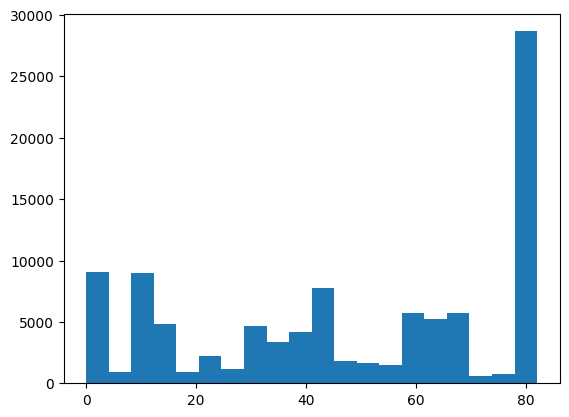

In [16]:

# podemos ver su distribución de caracteres tokenizados con un histograma
plt.hist(tokenized_text,bins=20)

In [17]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [18]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [19]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [20]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

In [21]:
# vemos la dimensión de los datos de entrenamiento
X.shape

(89800, 100)

In [22]:
vocab_size = len(chars_vocab)

### Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.

In [23]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone esta compuesto por 5 capas
* Capa de Embedding: no es una capa de embeding en si, pero existe una transformacion que se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.
* 2 Capas de SimpleRNN: con 200 parametros de salida, para cada capa se asigna un dropout de 10%
* Una capa densa con activacion softmax para medir las probabilidades de cada caracter entre 0 y 1
* La capa de salida con funcion de perdida sparse_categorical_crossentropy y el optimizador recomendado en clase rmsprop

Ademas se utilizara el Callback *ad-hoc* definido en clase que la calcule la perplejidad en cada epoch.

In [59]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:25: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_6              │ (None, None, 83)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 200)      │        56,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, None, 200)      │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, None, 83)       │        16,683 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,683 (600.32 KB)

 Trainable params: 153,683 (600.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl, model_name, patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.model_name = model_name
      self.patience_counter = 0
      self.patience = patience
      self.history_ppl = history_ppl

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save(f"{self.model_name}.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


#### Entrenamiento

In [ ]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl, "simplernn_model")], batch_size=512)

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - loss: 2.5778
 mean perplexity: 209.19595336914062 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 88s 452ms/step - loss: 2.1191
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - loss: 1.6646
 mean perplexity: 144.7485809326172 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 80s 456ms/step - loss: 1.6315
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - loss: 1.5456
 mean perplexity: 155.63442993164062 

176/176 ━━━━━━━━━━━━━━━━━━━━ 80s 455ms/step - loss: 1.5245
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - loss: 1.4744
 mean perplexity: 149.7363739013672 

176/176 ━━━━━━━━━━━━━━━━━━━━ 79s 449ms/step - loss: 1.4561
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - loss: 1.4204
 mean perplexity: 135.37307739257812 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 75s 427ms/step - loss: 1.4074
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - loss: 1.3776
 mean perplexity: 130.44174194335938 

Saved ne

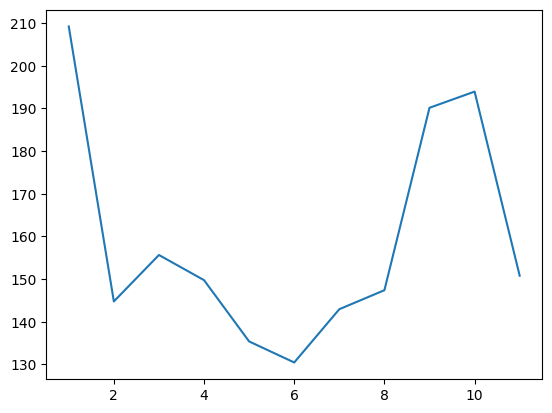

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

#### Se propone un segundo modelo para comparar el modelo anterior. En el mismo solo se modifican las capas intermedias, reemplazando SimpleRNN por LSTM

In [56]:
modelLSTM = Sequential()

modelLSTM.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
modelLSTM.add(LSTM(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
modelLSTM.add(LSTM(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
modelLSTM.add(Dense(vocab_size, activation='softmax'))
modelLSTM.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

modelLSTM.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_5              │ (None, None, 83)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, None, 200)      │       227,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, None, 200)      │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, None, 83)       │        16,683 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 564,683 (2.15 MB)

 Trainable params: 564,683 (2.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_ppl_2 = []
hist_2 = modelLSTM.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl_2, "lstm_model", patience=10)], batch_size=512)

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 3.2601
 mean perplexity: 23.014223098754883 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - loss: 3.1241
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 2.9766
 mean perplexity: 16.2117862701416 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - loss: 2.8286
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 2.3012
 mean perplexity: 42.051902770996094 

176/176 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - loss: 2.1873
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 1.9552
 mean perplexity: 140.86245727539062 

176/176 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - loss: 1.9063
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 1.8079
 mean perplexity: 204.78402709960938 

176/176 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - loss: 1.7796
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 1.7175
 mean perplexity: 305.9638366699219 

176/176 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - loss: 1.70

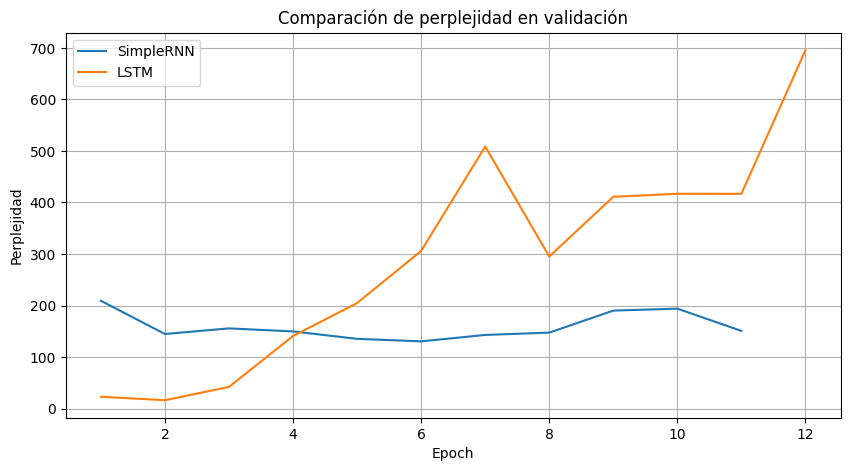

In [62]:
# Graficar ambas curvas de perplejidad en el mismo gráfico
epoch_count_1 = range(1, len(history_ppl) + 1)
epoch_count_2 = range(1, len(history_ppl_2) + 1)

plt.figure(figsize=(10, 5))
sns.lineplot(x=list(epoch_count_1), y=history_ppl, label='SimpleRNN')
sns.lineplot(x=list(epoch_count_2), y=history_ppl_2, label='LSTM')
plt.xlabel('Epoch')
plt.ylabel('Perplejidad')
plt.title('Comparación de perplejidad en validación')
plt.legend()
plt.grid(True)
plt.show()

### Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.

In [ ]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model('lstm_model.keras')

In [65]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [66]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 989ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Created dataset file at: .gradio\flagged\dataset1.csv
Keyboard interruption in main thread... closing server.


### Generación de secuencias

In [68]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [69]:
input_text='las mil y una n'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

'las mil y una noche y cuando llegó la 877ª no'

###  Beam search y muestreo aleatorio

In [70]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [71]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [79]:
# predicción con beam search
for temp in [0.5, 1, 5, 10]:
    salidas = beam_search(model,num_beams=10,num_words=50,input="las mil y una n", temp=temp)
    print(f"---- temp={temp} ----")
    print(decode(salidas[0]))

---- temp=0.5 ----
las mil y una noche pero cuando llegó la 877ª noche pero cuando l
---- temp=1 ----
las mil y una noche pero cuando llegó la 877ª noche pero cuando l
---- temp=5 ----
las mil y una noche pero cuando llegó la 877ª noche pero cuando l
---- temp=10 ----
las mil y una noche pero cuando llegó la 877ª noche pero cuando l
